In [1]:
import cv2
import numpy as np
import pandas as pd
import os

In [ ]:
import tensorflow as tf

In [3]:
tf.__version__

'2.15.0'

In [4]:
import cv2

In [5]:
import nibabel as nib
import numpy as np
import pandas as pd
import glob
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
from tifffile import imsave

In [6]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler()

In [7]:
path = 'D:\Brain tumor\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData/'

In [8]:
paths='D:\Brain tumor\Dataset\BraTSReg_Training_Data_v3/'

In [9]:
data_t1 = nib.load(path + 'BraTS20_Training_069/BraTS20_Training_069_t1.nii').get_fdata()
#print(data_t1.max())
#Scalers are applied to 1D so let us reshape and then reshape back to original shape.
data_t1 = minmax.fit_transform(data_t1.reshape(-1,data_t1.shape[-1])).reshape(data_t1.shape)
print(data_t1.shape)
#print(data_t1.max())

(240, 240, 155)


In [10]:
data_t1ce = nib.load(path + 'BraTS20_Training_069/BraTS20_Training_069_t1ce.nii').get_fdata()
data_t1ce = minmax.fit_transform(data_t1ce.reshape(-1,data_t1ce.shape[-1])).reshape(data_t1ce.shape)
data_t1ce.shape

(240, 240, 155)

In [11]:
data_t2 = nib.load(path + 'BraTS20_Training_069/BraTS20_Training_069_t2.nii').get_fdata()
data_t2 = minmax.fit_transform(data_t2.reshape(-1,data_t2.shape[-1])).reshape(data_t2.shape)
data_t2.shape

(240, 240, 155)

In [12]:
data_flair = nib.load(path + 'BraTS20_Training_069/BraTS20_Training_069_flair.nii').get_fdata()
data_flair = minmax.fit_transform(data_flair.reshape(-1,data_flair.shape[-1])).reshape(data_flair.shape)
data_flair.shape

(240, 240, 155)

In [13]:
data_mask = nib.load(path + 'BraTS20_Training_069/BraTS20_Training_069_seg.nii').get_fdata()
data_mask=data_mask.astype(np.uint8)
print(data_mask.shape)
print(np.unique(data_mask))   #0, 1, 2, 4 (Need to reencode to 0, 1, 2, 3)

(240, 240, 155)
[0 1 2 4]


In [14]:
data_mask[data_mask==4] = 3   #Reassign mask values 4 to 3
print(np.unique(data_mask)) 

[0 1 2 3]


In [15]:
import random
n=random.randint(0, data_mask.shape[2])

In [16]:
plt.figure(figsize=(12, 8))

<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

Text(0.5, 1.0, 'Image flair')

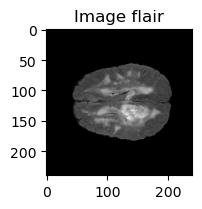

In [17]:
plt.subplot(231)
plt.imshow(data_flair[:,:,n], cmap='gray')
plt.title('Image flair')

Text(0.5, 1.0, 'Image t1')

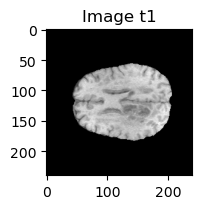

In [18]:
plt.subplot(231)
plt.imshow(data_t1[:,:,n], cmap='gray')
plt.title('Image t1')

Text(0.5, 1.0, 'Image t1ce')

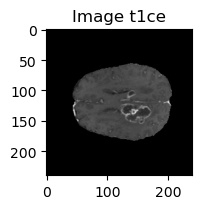

In [19]:
plt.subplot(232)
plt.imshow(data_t1ce[:,:,n], cmap='gray')
plt.title('Image t1ce')

Text(0.5, 1.0, 'Image t2-weighted')

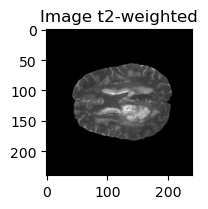

In [20]:
plt.subplot(234)
plt.imshow(data_t2[:,:,n], cmap='gray')
plt.title('Image t2-weighted')

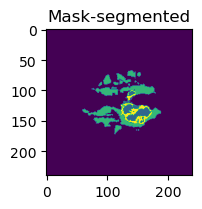

In [21]:
plt.subplot(235)
plt.imshow(data_mask[:,:,n])
plt.title('Mask-segmented')
plt.show()

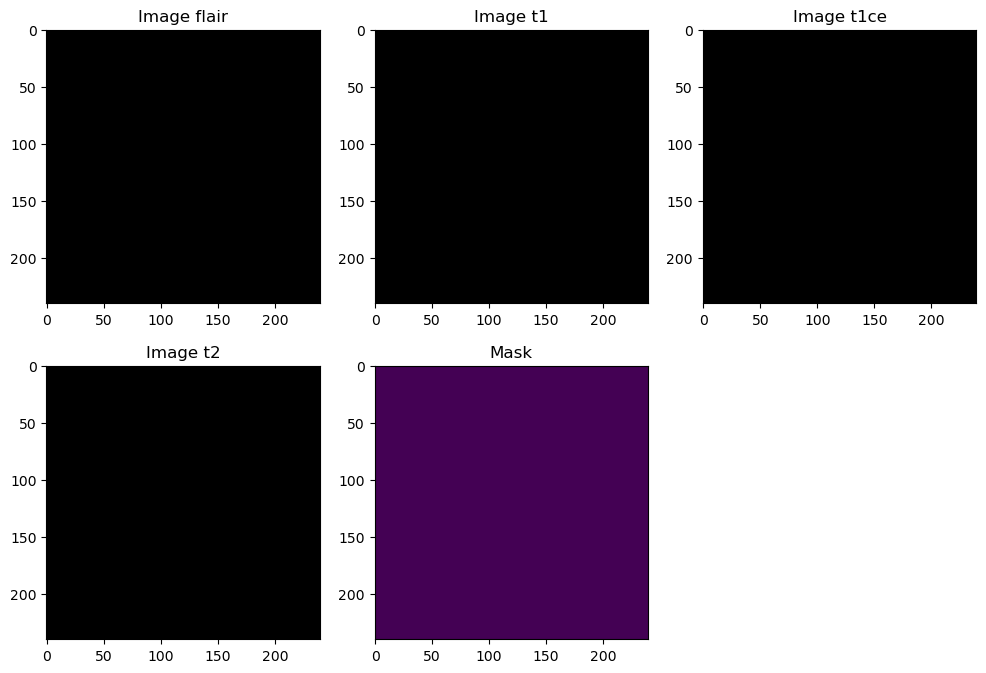

In [22]:
import random
n_slice=random.randint(0, data_mask.shape[2])

plt.figure(figsize=(12, 8))

plt.subplot(231)
plt.imshow(data_flair[:,:,n_slice], cmap='gray')
plt.title('Image flair')
plt.subplot(232)
plt.imshow(data_t1[:,:,n_slice], cmap='gray')
plt.title('Image t1')
plt.subplot(233)
plt.imshow(data_t1ce[:,:,n_slice], cmap='gray')
plt.title('Image t1ce')
plt.subplot(234)
plt.imshow(data_t2[:,:,n_slice], cmap='gray')
plt.title('Image t2')
plt.subplot(235)
plt.imshow(data_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [23]:
# Combining 3 different images to a single channel - to explore more
combined = np.stack([data_flair, data_t1ce,data_t2], axis=3)
combined.shape

(240, 240, 155, 3)

In [24]:
combined=combined[56:184, 56:184, 13:141] #Crop to 128x128x128x4
combined.shape

(128, 128, 128, 3)

In [25]:
#mask_data
data_mask = data_mask[56:184, 56:184, 13:141]
data_mask.shape

(128, 128, 128)

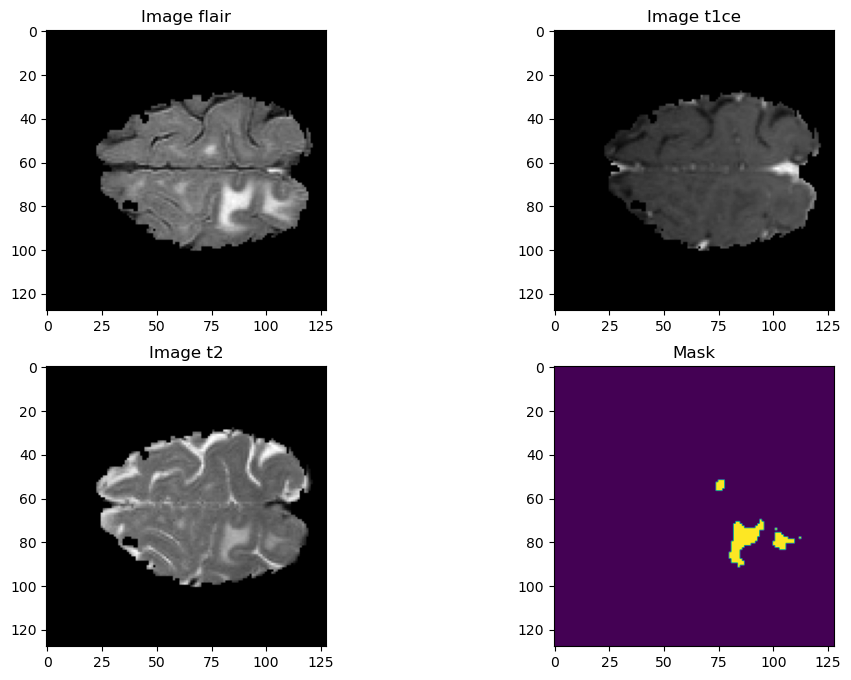

In [26]:
n_slice=random.randint(0, data_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(combined[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(combined[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(combined[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(data_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

In [27]:
data_mask = to_categorical(data_mask, num_classes=4)
data_mask.max()

1.0

In [28]:
#imsave('D:\Brain tumor/combined255.tif', combined)
#np.save('D:\Brain tumor/combined255.npy', combined)

In [29]:
#Now let's do it for all images

In [30]:
t2_list = sorted(glob.glob('D:\Brain tumor\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData/*/*t2.nii'))
t1ce_list = sorted(glob.glob('D:\Brain tumor\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData/*/*t1ce.nii'))
flair_list = sorted(glob.glob('D:\Brain tumor\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData/*/*flair.nii'))
mask_list = sorted(glob.glob('D:\Brain tumor\data\BraTS2020_TrainingData\MICCAI_BraTS2020_TrainingData/*/*seg.nii'))

In [31]:
#mask_list

In [32]:
#Each volume generates 18 64x64x64x4 sub-volumes. 
#Total 369 volumes = 6642 sub volumes

In [43]:
for img in range(len(t2_list)):   #Using t2_list as all lists are of same size
    #print("Now preparing image and masks number: ", img)
      
    temp_t2=nib.load(t2_list[img]).get_fdata()
    temp_t2=minmax.fit_transform(temp_t2.reshape(-1, temp_t2.shape[-1])).reshape(temp_t2.shape)
   
    temp_t1ce=nib.load(t1ce_list[img]).get_fdata()
    temp_t1ce=minmax.fit_transform(temp_t1ce.reshape(-1, temp_t1ce.shape[-1])).reshape(temp_t1ce.shape)
   
    temp_flair=nib.load(flair_list[img]).get_fdata()
    temp_flair=minmax.fit_transform(temp_flair.reshape(-1, temp_flair.shape[-1])).reshape(temp_flair.shape)
        
    temp_mask=nib.load(mask_list[img]).get_fdata()
    temp_mask=temp_mask.astype(np.uint8)
    temp_mask[temp_mask==4] = 3  #Reassign mask values 4 to 3
    #print(np.unique(temp_mask))
    temp_combined = np.stack([temp_flair, temp_t1ce, temp_t2], axis=3)
    #Crop to a size to be divisible by 64 so we can later extract 64x64x64 patches. 
    #cropping x, y, and z
    temp_combined=temp_combined[56:184, 56:184, 13:141]
    temp_mask = temp_mask[56:184, 56:184, 13:141]
    val, counts = np.unique(temp_mask, return_counts=True)
    if (1 - (counts[0]/counts.sum())) > 0.01:  #At least 1% useful volume with labels that are not 0
        print("Save Me")
        temp_mask= to_categorical(temp_mask, num_classes=4)
        np.save(r"D:\Brain tumor\data\BraTS2020_TrainingData\train\images\image_"+str(img)+'.npy',temp_combined)
        np.save(r"D:\Brain tumor\data\BraTS2020_TrainingData\train\masks\mask_"+str(img)+'.npy', temp_mask)
        
    else:
        print("I am useless") 

Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
I am useless
Save Me
I am useless
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save Me
Save

In [39]:
print(val)
print(counts)

[0 1 2 3]
[1885916   20589  148213   42434]


In [44]:
"""
Code for splitting folder into train, test, and val.
Once the new folders are created rename them and arrange in the format below to be used
for semantic segmentation using data generators. 

pip install split-folders
"""

'\nCode for splitting folder into train, test, and val.\nOnce the new folders are created rename them and arrange in the format below to be used\nfor semantic segmentation using data generators. \n\npip install split-folders\n'

In [51]:
pip install split-folders

Note: you may need to restart the kernel to use updated packages.


In [57]:
import splitfolders  # or import split_folders

input_folder = r"D:\Brain tumor\data\BraTS2020_TrainingData\train/"
output_folder = r"D:\Brain tumor\data\BraTS2020_TrainingData\train_sub/"
# Split with a ratio.
# To only split into training and validation set, set a tuple to `ratio`, i.e, `(.8, .2)`.
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.75, .25), group_prefix=None) # default values

Copying files: 688 files [09:28,  1.21 files/s]


### Data Generator

In [2]:
#from tifffile import imsave, imread
import os
import numpy as np


def load_img(img_dir, img_list):
    images=[]
    for i, image_name in enumerate(img_list):    
        if (image_name.split('.')[1] == 'npy'):
            
            image = np.load(img_dir+image_name)
                      
            images.append(image)
    images = np.array(images)
    
    return(images)


In [7]:
def imageLoader(img_dir, img_list, mask_dir, mask_list, batch_size):

    L = len(img_list)

    #keras needs the generator infinite, so we will use while true  
    while True:

        batch_start = 0
        batch_end = batch_size

        while batch_start < L:
            limit = min(batch_end, L)
                       
            X = load_img(img_dir, img_list[batch_start:limit])
            Y = load_img(mask_dir, mask_list[batch_start:limit])

            yield (X,Y) #a tuple with two numpy arrays with batch_size samples     

            batch_start += batch_size   
            batch_end += batch_size

In [8]:
#Test the generator

from matplotlib import pyplot as plt
import random

train_img_dir = "D:/Brain tumor/data/BraTS2020_TrainingData/train_sub/train/images/"
train_mask_dir = "D:/Brain tumor/data/BraTS2020_TrainingData/train_sub/train/masks/"
train_img_list=os.listdir(train_img_dir)
train_mask_list = os.listdir(train_mask_dir)

batch_size = 2

train_img_datagen = imageLoader(train_img_dir, train_img_list, 
                                train_mask_dir, train_mask_list, batch_size)

#Verify generator.... In python 3 next() is renamed as __next__()
img, msk = train_img_datagen.__next__()


img_num = random.randint(0,img.shape[0]-1)
test_img=img[img_num]
test_mask=msk[img_num]
test_mask=np.argmax(test_mask, axis=3)

n_slice=random.randint(0, test_mask.shape[2])
plt.figure(figsize=(12, 8))

plt.subplot(221)
plt.imshow(test_img[:,:,n_slice, 0], cmap='gray')
plt.title('Image flair')
plt.subplot(222)
plt.imshow(test_img[:,:,n_slice, 1], cmap='gray')
plt.title('Image t1ce')
plt.subplot(223)
plt.imshow(test_img[:,:,n_slice, 2], cmap='gray')
plt.title('Image t2')
plt.subplot(224)
plt.imshow(test_mask[:,:,n_slice])
plt.title('Mask')
plt.show()

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'D:/Brain tumor/data/BraTS2020_TrainingData/train_sub/train/images/'

### U-Net model and train it 

In [1]:
import os
import numpy as np
from custom_datagen import imageLoader
#import tensorflow as tf
import keras
from matplotlib import pyplot as plt
import glob
import random

ModuleNotFoundError: No module named 'custom_datagen'